In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots
import pandas as pd

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


In [18]:
# total time estimation
num_test_samples=1000
num_posterior_samples=100
time_per_sample=10
noise_levels=3
procedures=2
num_diagnostics = 2
total_time = num_diagnostics * num_test_samples*time_per_sample*noise_levels*procedures
print("Total time: ", total_time/(60*60), " hours")

Total time:  33.333333333333336  hours


In [2]:
# check hyperparameter tuning results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5]
lambda_values  = [50, 100, 200, 300, 400, 500]
zeta_values = [0.2, 0.4, 0.6, 0.8, 1.0]

results = []
for noise in noise_levels:
    for zeta in zeta_values:
        for lambda_ in lambda_values:
            csv_name = f"metrics_csv/metrics_diffusion_sxr_{noise}_zeta{zeta}_lambda{lambda_}.csv"
            if os.path.exists(csv_name):
                df = pd.read_csv(csv_name)
                df["noise"] = noise
                df["zeta"] = zeta
                df["lambda"] = lambda_
                results.append(df)
            else:
                print(f"File {csv_name} not found.")

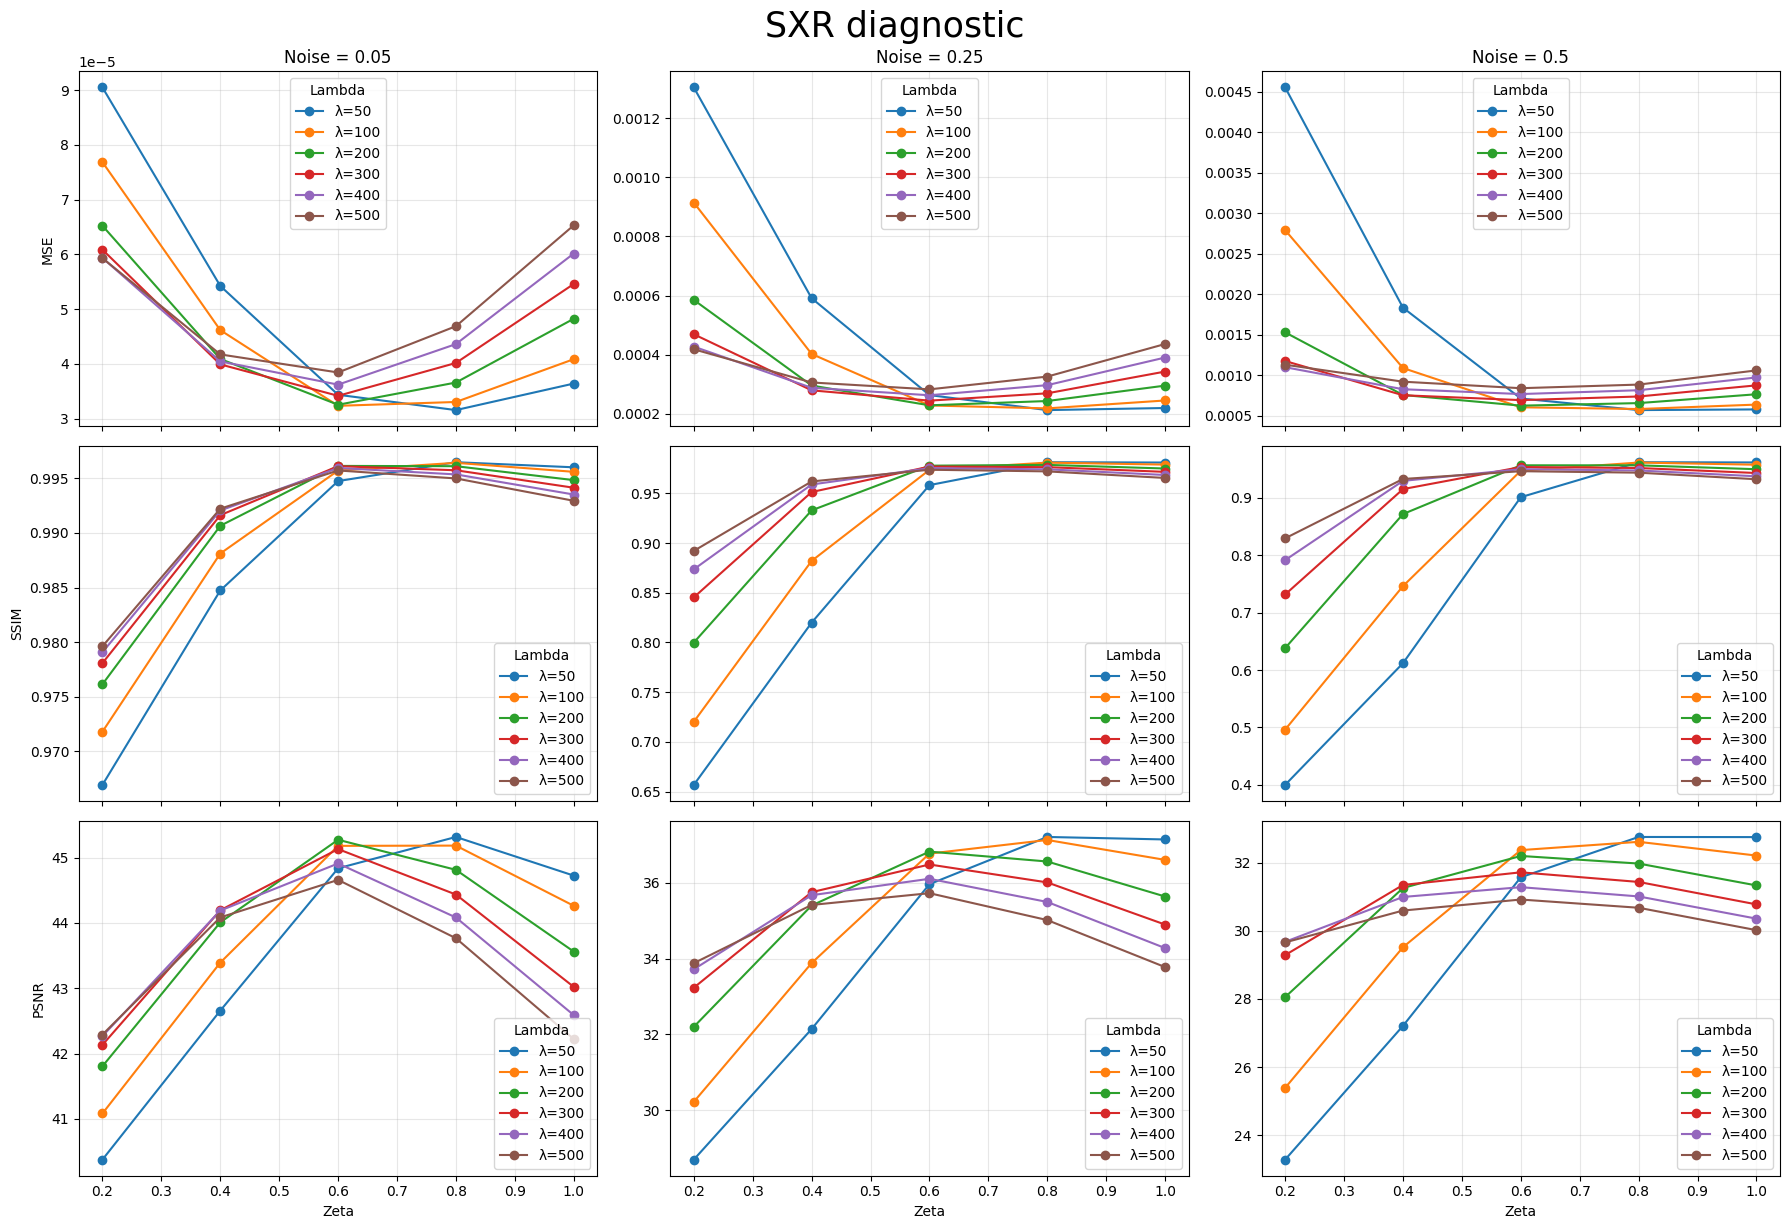

In [3]:
metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}

df_all = pd.concat(results, ignore_index=True)
df_avg = df_all.groupby(["noise", "zeta", "lambda"], as_index=False)[metrics].mean()

fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for r, metric in enumerate(metrics):
    for c, noise in enumerate(noise_levels):
        a = ax[r, c]
        df_noise = df_avg[df_avg["noise"] == noise] 

        for lambda_ in lambda_values:
            df_curve = df_noise[df_noise["lambda"] == lambda_].sort_values("zeta")
            a.plot(df_curve["zeta"], df_curve[metric], marker="o", label=f"λ={lambda_}")

        if r == 0:
            a.set_title(f"Noise = {noise}")
        if c == 0:
            a.set_ylabel(metric_labels[metric])
        if r == 2:
            a.set_xlabel("Zeta")

        a.grid(alpha=0.3)

# keep legends only on the rightmost column to reduce clutter
for r in range(3):
    for i in range(3):
        if r==0:
            ax[r, i].legend(title="Lambda", loc="upper center")
        else:
            ax[r, i].legend(title="Lambda", loc="lower right")

plt.tight_layout()
plt.suptitle("SXR diagnostic", y=1.02, fontsize=25)
#plt.savefig("sxr_hyperparameter_tuning_results.png", dpi=300)
plt.show()



In [4]:
# check hyperparameter tuning results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.1, 0.5, 1.0] #[0.05, 0.25, 0.5] #[0.1, 0.5, 1.0]
lambda_values  = [50, 100, 200, 300, 400, 500]
zeta_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4]

results = []
for noise in noise_levels:
    for zeta in zeta_values:
        for lambda_ in lambda_values:
            csv_name = f"metrics_csv/metrics_diffusion_dmpx_{noise}_zeta{zeta}_lambda{lambda_}.csv"
            if os.path.exists(csv_name):
                df = pd.read_csv(csv_name)
                df["noise"] = noise
                df["zeta"] = zeta
                df["lambda"] = lambda_
                results.append(df)
            else:
                print(f"File {csv_name} not found.")

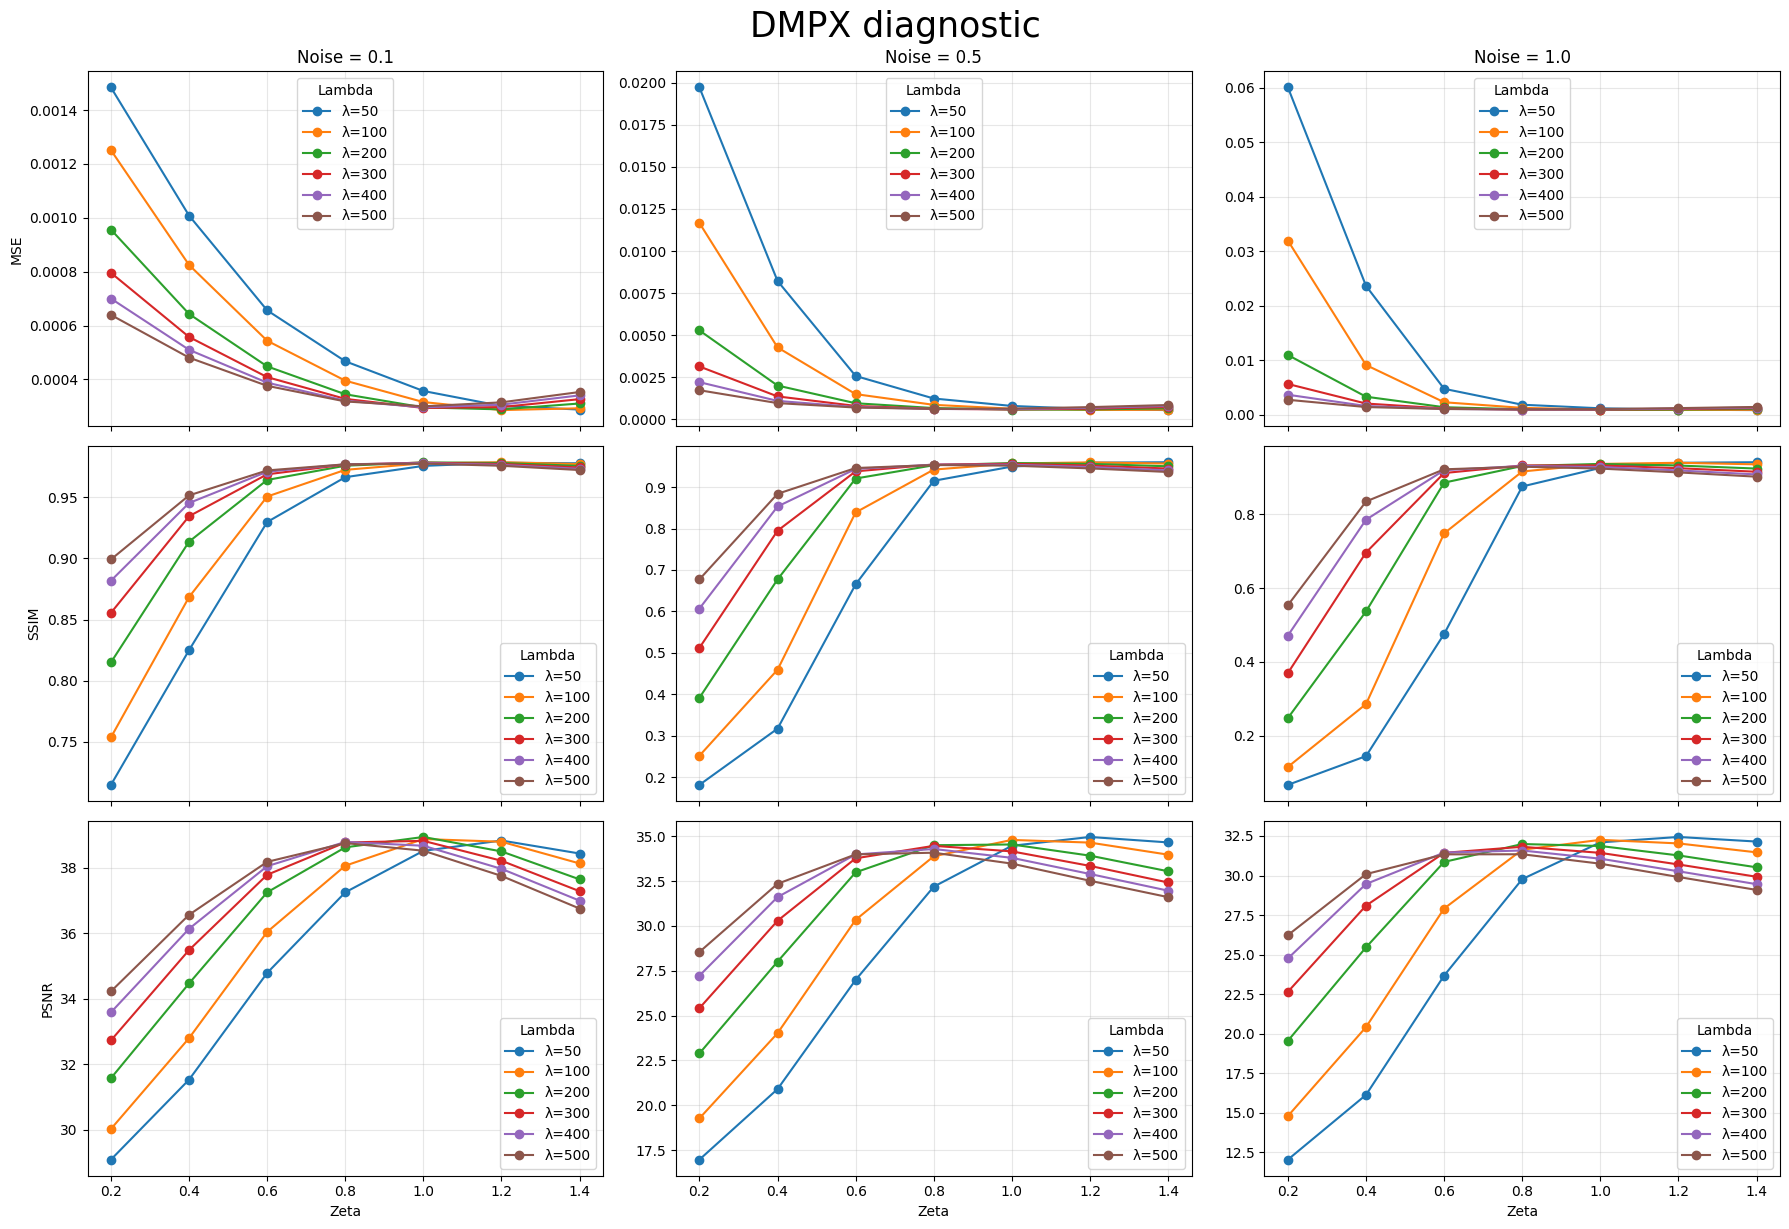

In [5]:
metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}

df_all = pd.concat(results, ignore_index=True)
df_avg = df_all.groupby(["noise", "zeta", "lambda"], as_index=False)[metrics].mean()

fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for r, metric in enumerate(metrics):
    for c, noise in enumerate(noise_levels):
        a = ax[r, c]
        df_noise = df_avg[df_avg["noise"] == noise] 

        for lambda_ in lambda_values:
            if noise>0.05 or lambda_>100:
                df_curve = df_noise[df_noise["lambda"] == lambda_].sort_values("zeta")
                a.plot(df_curve["zeta"], df_curve[metric], marker="o", label=f"λ={lambda_}")
            else:
                a.plot([], [], marker="o", label=f"λ={lambda_}")


        if r == 0:
            a.set_title(f"Noise = {noise}")
        if c == 0:
            a.set_ylabel(metric_labels[metric])
        if r == 2:
            a.set_xlabel("Zeta")

        a.grid(alpha=0.3)

# keep legends only on the rightmost column to reduce clutter
for r in range(3):
    for i in range(3):
        if r==0:
            ax[r, i].legend(title="Lambda", loc="upper center")
        else:
            ax[r, i].legend(title="Lambda", loc="lower right")

plt.tight_layout()
plt.suptitle("DMPX diagnostic", y=1.02, fontsize=25)
#plt.savefig("dmpx_hyperparameter_tuning_results.png", dpi=300)
plt.show()



## Pilatus

No clipping

In [7]:
# check hyperparameter tuning results

noise_levels = [0.07, 0.35, 0.7] #[0.05, 0.25, 0.5] #[0.1, 0.5, 1.0]
lambda_values  = [50, 100, 200, 300, 400, 500]
zeta_values = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4]

results = []
for noise in noise_levels:
    for zeta in zeta_values:
        for lambda_ in lambda_values:
            csv_name = f"metrics_csv/metrics_diffusion_pilatus_{noise}_zeta{zeta}_lambda{lambda_}_clipFalse.csv"
            if os.path.exists(csv_name):
                df = pd.read_csv(csv_name)
                df["noise"] = noise
                df["zeta"] = zeta
                df["lambda"] = lambda_
                results.append(df)
            else:
                print(f"File {csv_name} not found.")

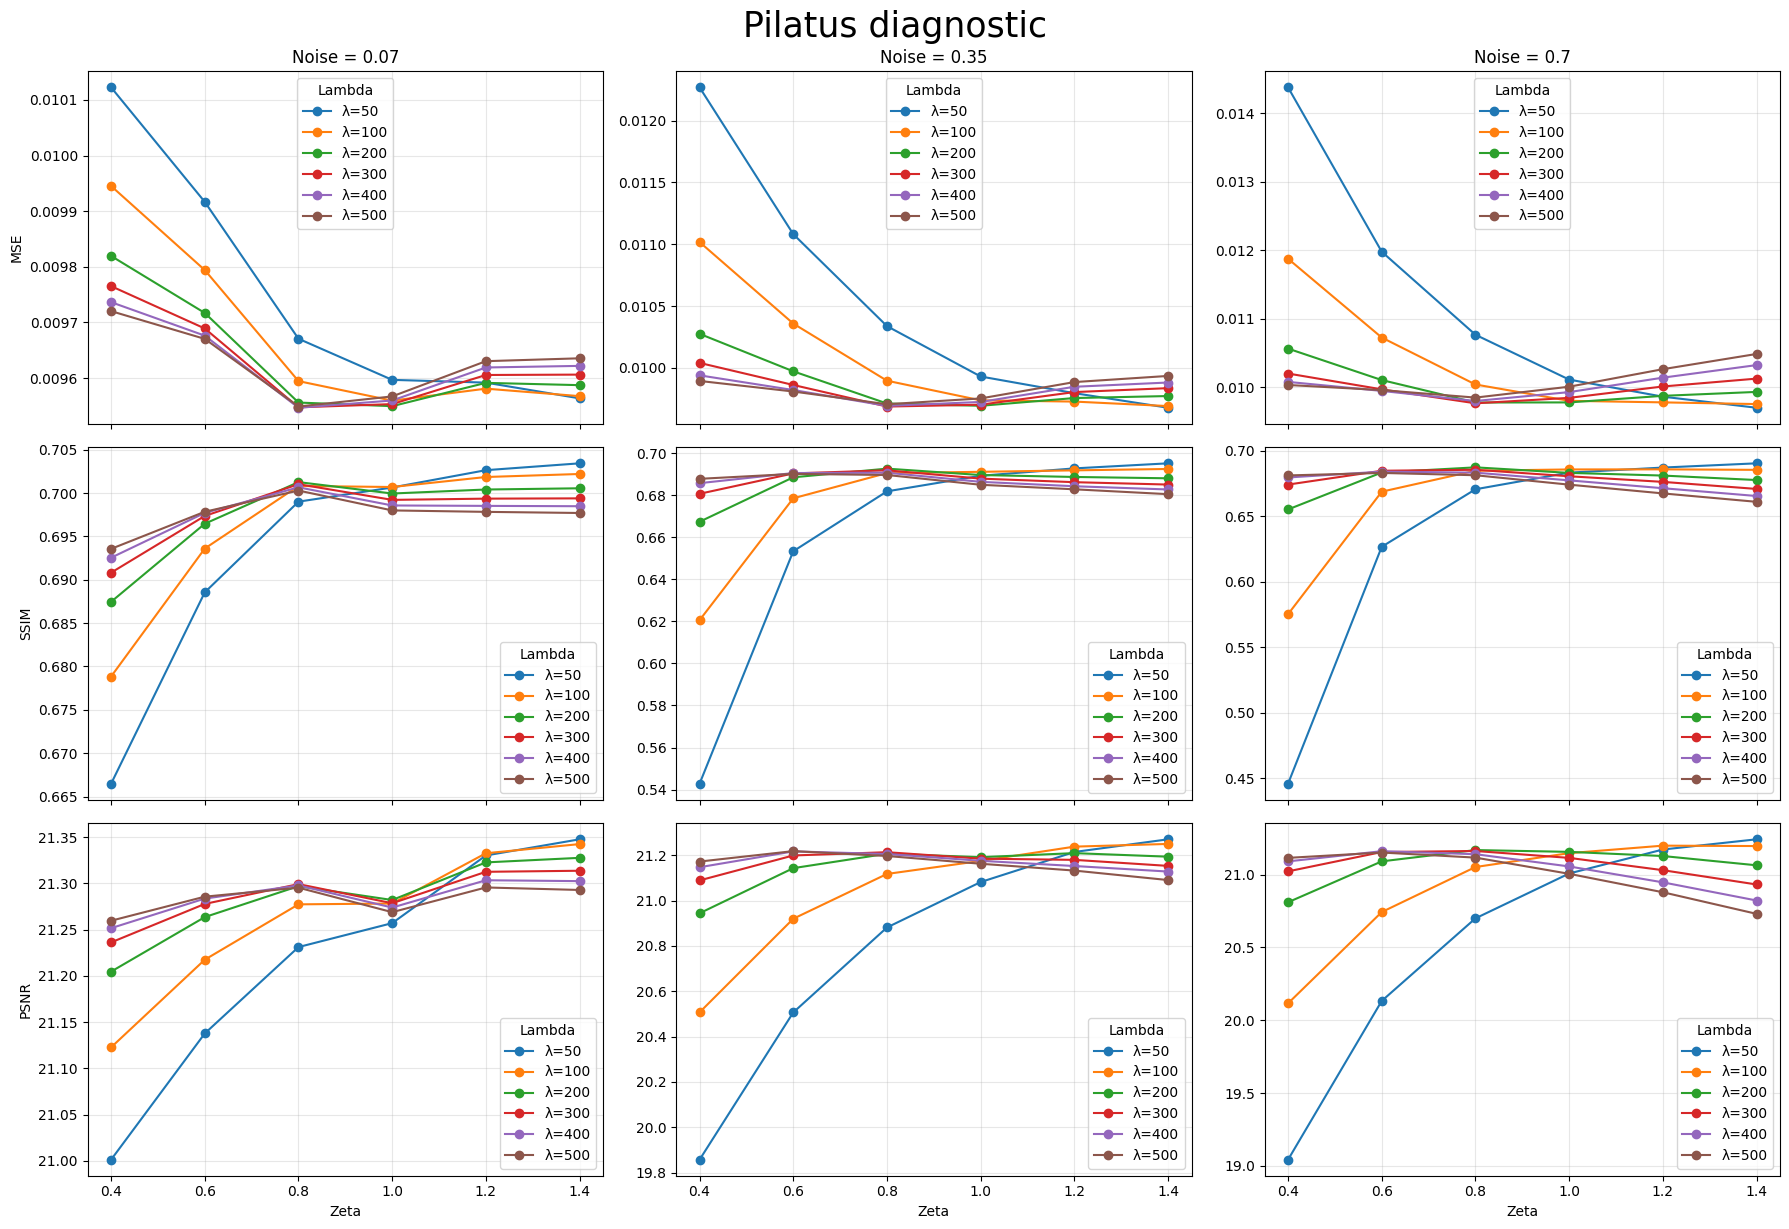

In [8]:
metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}

df_all = pd.concat(results, ignore_index=True)
df_avg = df_all.groupby(["noise", "zeta", "lambda"], as_index=False)[metrics].mean()

fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for r, metric in enumerate(metrics):
    for c, noise in enumerate(noise_levels):
        a = ax[r, c]
        df_noise = df_avg[df_avg["noise"] == noise] 

        for lambda_ in lambda_values:
            #if noise>0.05 or lambda_>100:
            df_curve = df_noise[df_noise["lambda"] == lambda_].sort_values("zeta")
            a.plot(df_curve["zeta"], df_curve[metric], marker="o", label=f"λ={lambda_}")
            # else:
            #     a.plot([], [], marker="o", label=f"λ={lambda_}")


        if r == 0:
            a.set_title(f"Noise = {noise}")
        if c == 0:
            a.set_ylabel(metric_labels[metric])
        if r == 2:
            a.set_xlabel("Zeta")

        a.grid(alpha=0.3)

# keep legends only on the rightmost column to reduce clutter
for r in range(3):
    for i in range(3):
        if r==0:
            ax[r, i].legend(title="Lambda", loc="upper center")
        else:
            ax[r, i].legend(title="Lambda", loc="lower right")

plt.tight_layout()
plt.suptitle("Pilatus diagnostic", y=1.02, fontsize=25)
#plt.savefig("pilatus_noclip_hyperparameter_tuning_results.png", dpi=300)
plt.show()



With clipping

In [9]:
# check hyperparameter tuning results

noise_levels = [0.07, 0.35, 0.7] #[0.05, 0.25, 0.5] #[0.1, 0.5, 1.0]
lambda_values  = [50, 100, 200, 300, 400, 500]
zeta_values = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4]

results = []
for noise in noise_levels:
    for zeta in zeta_values:
        for lambda_ in lambda_values:
            csv_name = f"metrics_csv/metrics_diffusion_pilatus_{noise}_zeta{zeta}_lambda{lambda_}_clipTrue.csv"
            if os.path.exists(csv_name):
                df = pd.read_csv(csv_name)
                df["noise"] = noise
                df["zeta"] = zeta
                df["lambda"] = lambda_
                results.append(df)
            else:
                print(f"File {csv_name} not found.")

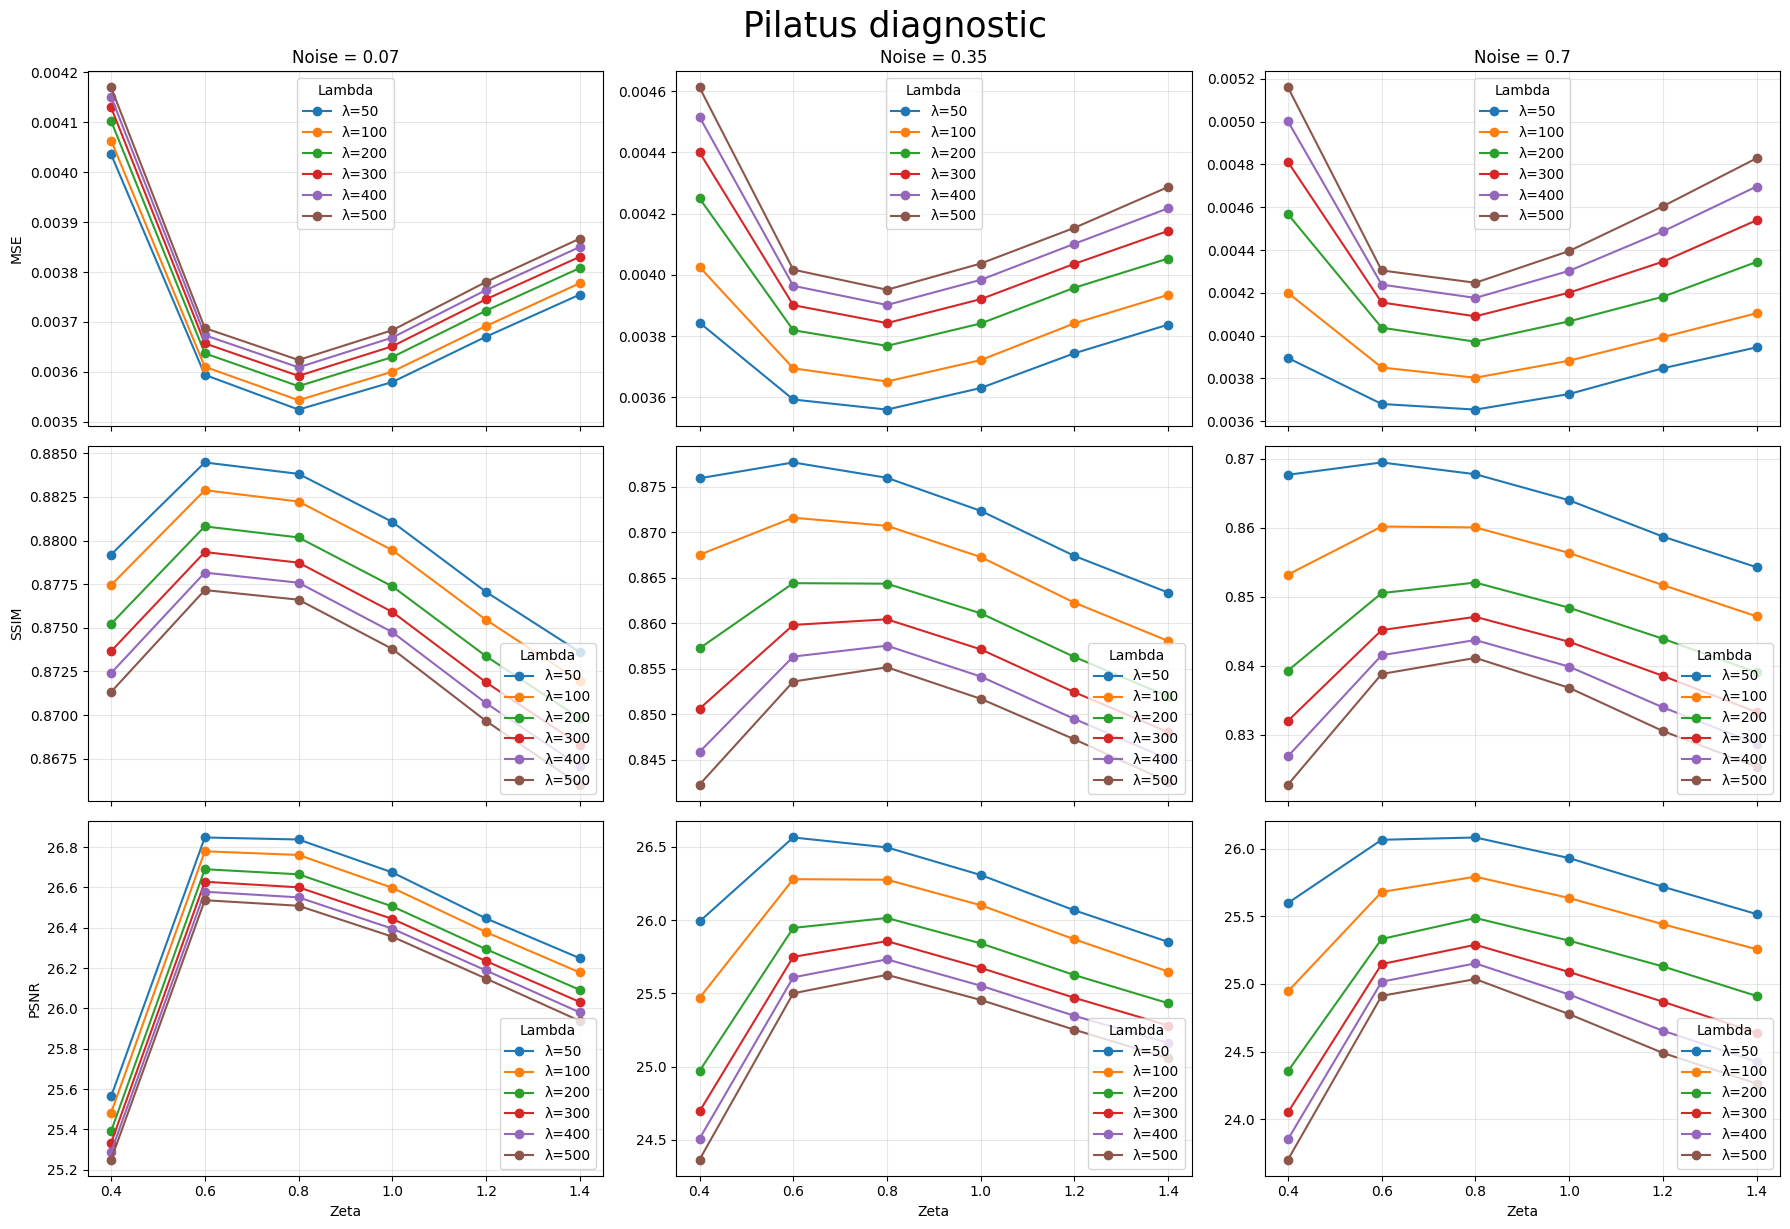

In [10]:
metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}

df_all = pd.concat(results, ignore_index=True)
df_avg = df_all.groupby(["noise", "zeta", "lambda"], as_index=False)[metrics].mean()

fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for r, metric in enumerate(metrics):
    for c, noise in enumerate(noise_levels):
        a = ax[r, c]
        df_noise = df_avg[df_avg["noise"] == noise] 

        for lambda_ in lambda_values:
            #if noise>0.05 or lambda_>100:
            df_curve = df_noise[df_noise["lambda"] == lambda_].sort_values("zeta")
            a.plot(df_curve["zeta"], df_curve[metric], marker="o", label=f"λ={lambda_}")
            # else:
            #     a.plot([], [], marker="o", label=f"λ={lambda_}")


        if r == 0:
            a.set_title(f"Noise = {noise}")
        if c == 0:
            a.set_ylabel(metric_labels[metric])
        if r == 2:
            a.set_xlabel("Zeta")

        a.grid(alpha=0.3)

# keep legends only on the rightmost column to reduce clutter
for r in range(3):
    for i in range(3):
        if r==0:
            ax[r, i].legend(title="Lambda", loc="upper center")
        else:
            ax[r, i].legend(title="Lambda", loc="lower right")

plt.tight_layout()
plt.suptitle("Pilatus diagnostic", y=1.02, fontsize=25)
#plt.savefig("pilatus_withclip_hyperparameter_tuning_results.png", dpi=300)
plt.show()

